# 08. Финальное тестирование моделей на отложенной выборке cs-test.csv

В этом ноутбуке:
- загрузка валидационных данных (для расчёта контрольных метрик)
- загрузка тестовых данных (без меток) и их предобработка
- создание файла submission.csv для отправки на Kaggle
- расчёт метрик на валидационной выборке и сравнение с предыдущими результатами

### 1. Импорт библиотек и настройка путей

In [4]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import os

# Создаём папку для графиков
FIGURES_DIR = '../reports/figures/08_final_test'
os.makedirs(FIGURES_DIR, exist_ok=True)

### 2. Загрузка и предобработка валидационных данных (контрольная проверка)

Поскольку в файле cs-test.csv нет целевой переменной, используем валидационную выборку для расчёта метрик и убеждаемся, что модели стабильны.

In [5]:
# Загрузка валидационных данных (сохранены при предобработке)
X_val = np.load('../data/processed/X_val_scaled.npy')
y_val = np.load('../data/processed/y_val.npy')
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер валидационной выборки: 29944 строк
Доля дефолтов в валидационной выборке: 0.0660


### 3. Загрузка обученных моделей

In [6]:
models = {}

# Логистическая регрессия
with open('../models/logistic_regression.pkl', 'rb') as f:
    models['Logistic Regression'] = pickle.load(f)

# Случайный лес
with open('../models/random_forest.pkl', 'rb') as f:
    models['Random Forest'] = pickle.load(f)

# XGBoost
with open('../models/xgboost.pkl', 'rb') as f:
    models['XGBoost'] = pickle.load(f)

# CatBoost
with open('../models/catboost.pkl', 'rb') as f:
    models['CatBoost'] = pickle.load(f)

print("Все модели загружены.")

Все модели загружены.


### 4. Расчёт метрик на валидационной выборке (контроль)

In [7]:
results_val = {}

for name, model in models.items():
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results_val[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc
    }
    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print()

Logistic Regression:
  Precision: 0.2564
  Recall:    0.6194
  F1-score:  0.3627
  ROC-AUC:   0.8165

Random Forest:
  Precision: 0.2234
  Recall:    0.7100
  F1-score:  0.3399
  ROC-AUC:   0.8577

XGBoost:
  Precision: 0.2134
  Recall:    0.7713
  F1-score:  0.3342
  ROC-AUC:   0.8653

CatBoost:
  Precision: 0.2125
  Recall:    0.7687
  F1-score:  0.3329
  ROC-AUC:   0.8649



### 5. Сравнение с валидационными метриками

In [15]:
# Данные из предыдущих расчётов (метрики на той же валидационной выборке)
validation_metrics_previous = {
    'Logistic Regression': {'ROC-AUC': 0.817, 'Recall': 0.619},
    'Random Forest':       {'ROC-AUC': 0.858, 'Recall': 0.710},
    'XGBoost':             {'ROC-AUC': 0.865, 'Recall': 0.771},
    'CatBoost':            {'ROC-AUC': 0.865, 'Recall': 0.769}
}

print("Сравнение метрик на валидационной выборке (текущий расчёт vs предыдущие результаты):")
print("-" * 70)
for name in models.keys():
    old_auc = validation_metrics_previous[name]['ROC-AUC']
    new_auc = results_val[name]['ROC-AUC']
    old_rec = validation_metrics_previous[name]['Recall']
    new_rec = results_val[name]['Recall']
    print(f"{name}:")
    print(f"  ROC-AUC: предыдущие = {old_auc:.4f}, сейчас = {new_auc:.4f}, отклонение = {abs(old_auc - new_auc):.4f}")
    print(f"  Recall:  предыдущие = {old_rec:.4f}, сейчас = {new_rec:.4f}, отклонение = {abs(old_rec - new_rec):.4f}")
    print()

Сравнение метрик на валидационной выборке (текущий расчёт vs предыдущие результаты):
----------------------------------------------------------------------
Logistic Regression:
  ROC-AUC: предыдущие = 0.8170, сейчас = 0.8165, отклонение = 0.0005
  Recall:  предыдущие = 0.6190, сейчас = 0.6194, отклонение = 0.0004

Random Forest:
  ROC-AUC: предыдущие = 0.8580, сейчас = 0.8577, отклонение = 0.0003
  Recall:  предыдущие = 0.7100, сейчас = 0.7100, отклонение = 0.0000

XGBoost:
  ROC-AUC: предыдущие = 0.8650, сейчас = 0.8653, отклонение = 0.0003
  Recall:  предыдущие = 0.7710, сейчас = 0.7713, отклонение = 0.0003

CatBoost:
  ROC-AUC: предыдущие = 0.8650, сейчас = 0.8649, отклонение = 0.0001
  Recall:  предыдущие = 0.7690, сейчас = 0.7687, отклонение = 0.0003



### 6. Подготовка предсказаний для тестовой выборки (cs-test.csv) и отправка на Kaggle

Поскольку в тестовом наборе нет целевой переменной, мы не можем вычислить метрики, но можем сгенерировать файл для соревнования.

In [10]:
# Загрузка тестовых данных
df_test = pd.read_csv('../data/raw/cs-test.csv')
test_ids = df_test['Unnamed: 0']
df_test = df_test.drop('Unnamed: 0', axis=1)

# Если в тестовых данных случайно оказалась целевая переменная – удаляем
if 'SeriousDlqin2yrs' in df_test.columns:
    df_test = df_test.drop('SeriousDlqin2yrs', axis=1)

# Заполнение пропусков (те же значения, что при обучении)
median_income = 5400.0
mode_dependents = 0.0
df_test['MonthlyIncome'] = df_test['MonthlyIncome'].fillna(median_income)
df_test['NumberOfDependents'] = df_test['NumberOfDependents'].fillna(mode_dependents)

# Масштабирование (выбросы НЕ удаляются, чтобы сохранить все строки)
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
X_test_scaled = scaler.transform(df_test)

# Предсказания лучшей модели (XGBoost)
best_model = models['XGBoost']
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Создание submission.csv
submission = pd.DataFrame({'Id': test_ids, 'Probability': y_test_proba})
submission.to_csv('submission.csv', index=False)
print("submission.csv создан. Первые 5 строк:")
print(submission.head())

submission.csv создан. Первые 5 строк:
   Id  Probability
0   1     0.517659
1   2     0.404609
2   3     0.158339
3   4     0.550699
4   5     0.622965


### 7. Визуализация матриц ошибок на валидационной выборке (опционально)

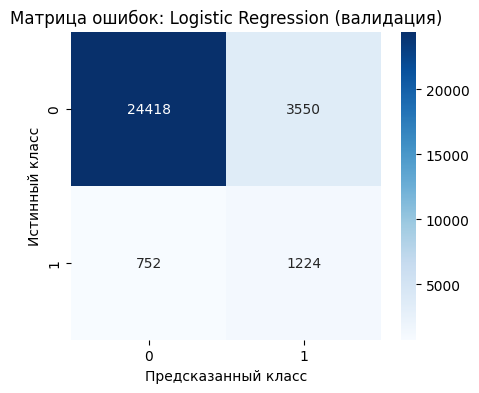

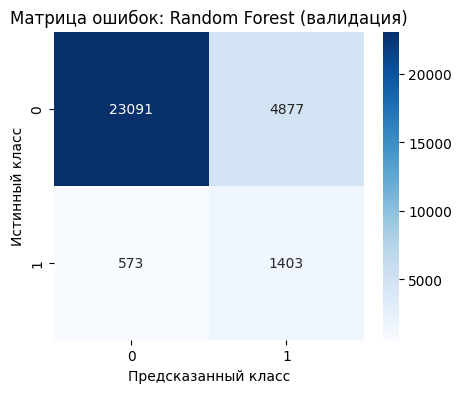

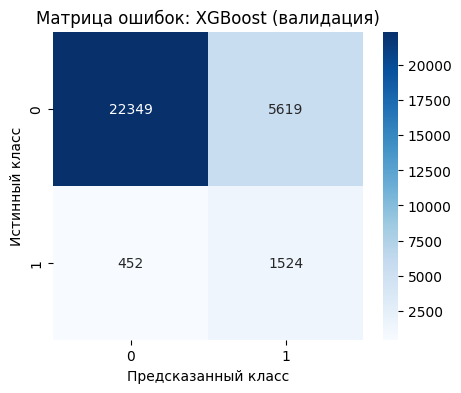

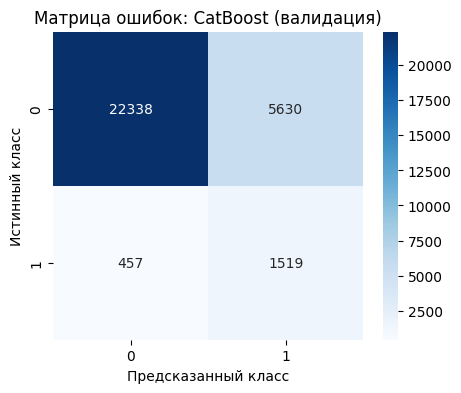

In [11]:
for name, model in models.items():
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок: {name} (валидация)')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.savefig(os.path.join(FIGURES_DIR, f'{name.replace(" ", "_")}_confusion_matrix_val.png'), bbox_inches='tight')
    plt.show()

### 8. ROC-кривые на валидационной выборке (совмещённые)

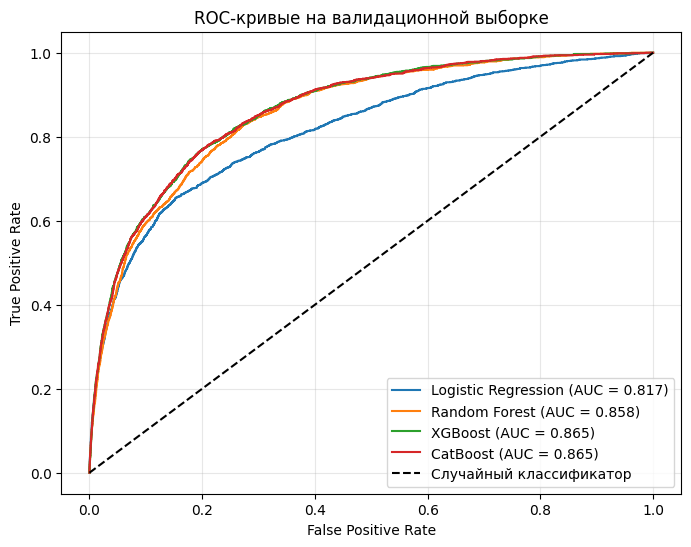

In [12]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на валидационной выборке')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curves_val.png'), bbox_inches='tight')
plt.show()